# Notebook 8: Data Visualization and Storytelling

## Project Name
PhonePe Transaction Insights

## Objective
This notebook focuses on analyzing the SQL output data using Python libraries such as Pandas, Matplotlib, Seaborn, and Plotly.  
The goal is to create meaningful visualizations, identify top-performing states/districts/categories, and derive business insights that support decision-making.

## Key Areas Covered
- Transaction Analysis
- User Engagement Analysis
- Insurance Analysis
- Geographic Insights
- Trend Analysis
- Business Storytelling

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sqlalchemy import create_engine

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

## Database Connection
In this section, we connect to the SQL database and fetch the required tables for analysis.

In [2]:
user = "root"
password = "12345"
host = "localhost"
port = "3306"
database = "phonepe_insights"

engine = create_engine(f"mysql+pymysql://{user}:{password}@{host}:{port}/{database}")

In [3]:
aggregated_transaction = pd.read_sql("SELECT * FROM aggregated_transaction", engine)
aggregated_user = pd.read_sql("SELECT * FROM aggregated_user", engine)
aggregated_insurance = pd.read_sql("SELECT * FROM aggregated_insurance", engine)

map_transaction = pd.read_sql("SELECT * FROM map_transaction", engine)
map_user = pd.read_sql("SELECT * FROM map_user", engine)
map_insurance = pd.read_sql("SELECT * FROM map_insurance", engine)

top_transaction = pd.read_sql("SELECT * FROM top_transaction", engine)
top_user = pd.read_sql("SELECT * FROM top_user", engine)
top_insurance = pd.read_sql("SELECT * FROM top_insurance", engine)

In [4]:
aggregated_transaction.head()

,id,state,year,quarter,transaction_type,transaction_count,transaction_amount
0,1,Andaman & Nicobar Islands,2018,1,Recharge & bill payments,4200,1.845307e+06
1,2,Andaman & Nicobar Islands,2018,1,Peer-to-peer payments,1871,1.213866e+07
2,3,Andaman & Nicobar Islands,2018,1,Merchant payments,298,4.525072e+05
3,4,Andaman & Nicobar Islands,2018,1,Financial Services,33,1.060142e+04
4,5,Andaman & Nicobar Islands,2018,1,Others,256,1.846899e+05


## Data Preparation
Before creating visualizations, we ensure that numeric fields are correctly typed and that year/quarter values are usable for grouped analysis.

In [5]:
for df in [aggregated_transaction, aggregated_user, aggregated_insurance,
           map_transaction, map_user, map_insurance,
           top_transaction, top_user, top_insurance]:
    for col in df.columns:
        if "amount" in col.lower() or "count" in col.lower() or "users" in col.lower() or "opens" in col.lower():
            df[col] = pd.to_numeric(df[col], errors="coerce")

# Chart 1: Top 10 States by Transaction Amount

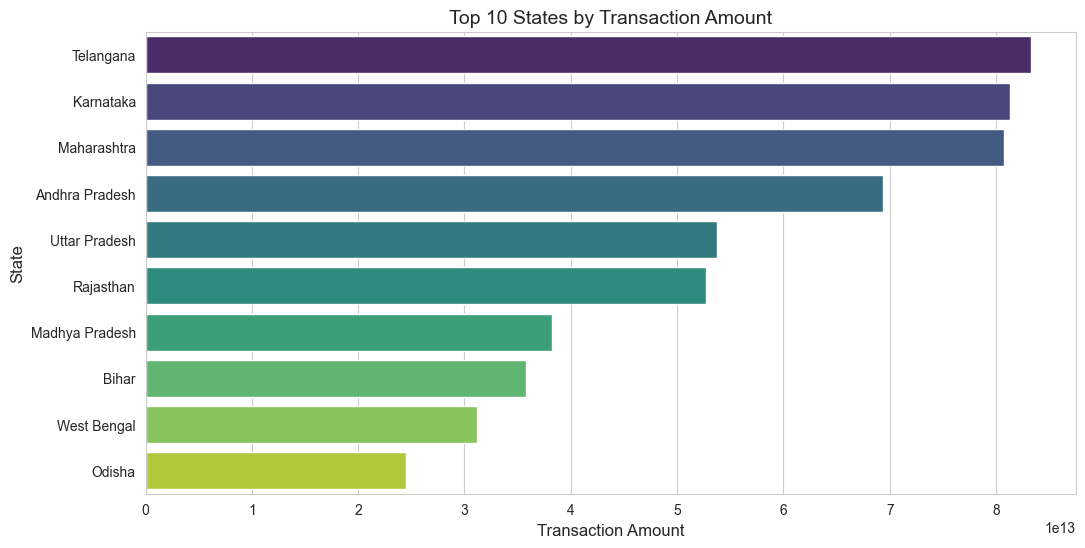

In [6]:
chart1 = aggregated_transaction.groupby("state", as_index=False)["transaction_amount"].sum()
chart1 = chart1.sort_values("transaction_amount", ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(data=chart1, x="transaction_amount", y="state", palette="viridis")
plt.title("Top 10 States by Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("State")
plt.show()

### Why did you pick this chart?
A horizontal bar chart is ideal for comparing ranked values across states clearly and quickly.

### Insights found
This chart highlights the states contributing the highest share of total transaction value. It helps identify dominant markets in the digital payments ecosystem.

### Business impact
These insights can help prioritize premium campaigns, partnerships, and infrastructure investment in high-value states.  
If a few states contribute too much share, it may also indicate market concentration risk.

# Chart 2: Top 10 States by Transaction Count

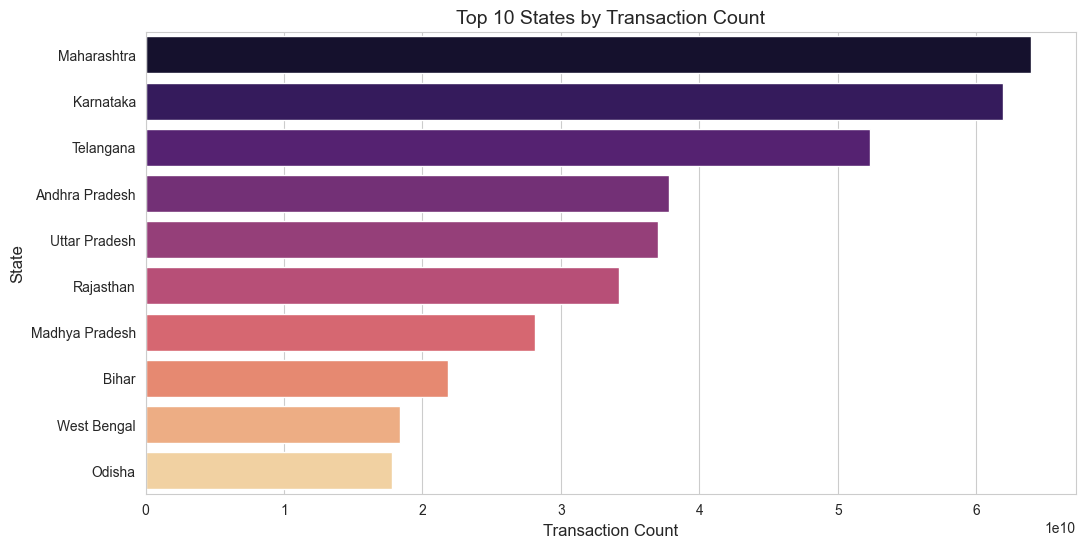

In [7]:
chart2 = aggregated_transaction.groupby("state", as_index=False)["transaction_count"].sum()
chart2 = chart2.sort_values("transaction_count", ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(data=chart2, x="transaction_count", y="state", palette="magma")
plt.title("Top 10 States by Transaction Count")
plt.xlabel("Transaction Count")
plt.ylabel("State")
plt.show()

### Why did you pick this chart?
A bar chart makes it easy to compare usage frequency across states.

### Insights found
This chart shows which states generate the largest volume of digital transactions.  
A state may rank high in count even if its transaction amount is not proportionally high.

### Business impact
This helps identify high-engagement markets suitable for loyalty programs and user retention strategies.  
A mismatch between count and amount may reveal low-ticket but highly active markets.

# Chart 3: Transaction Share by Payment Category

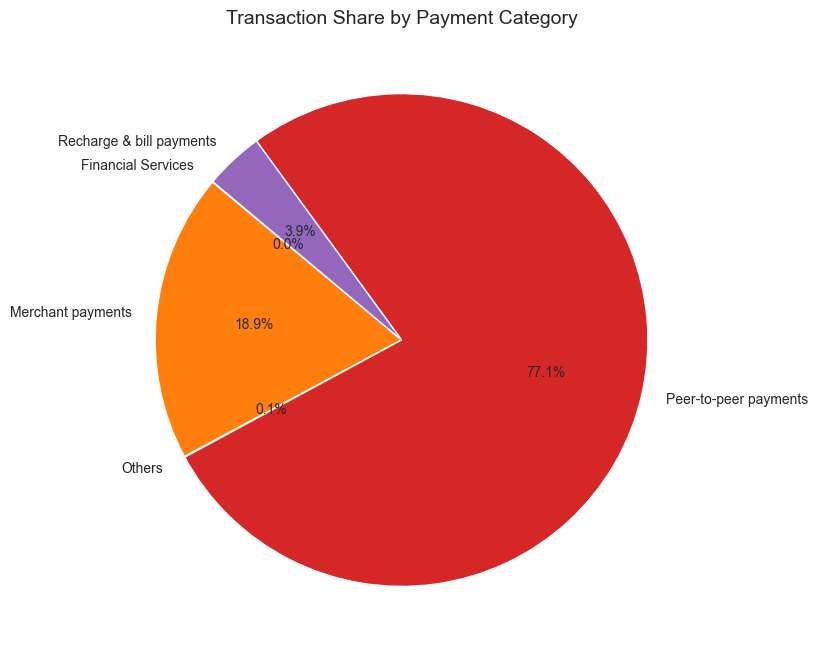

In [8]:
chart3 = aggregated_transaction.groupby("transaction_type", as_index=False)["transaction_amount"].sum()

plt.figure(figsize=(8,8))
plt.pie(chart3["transaction_amount"], labels=chart3["transaction_type"], autopct="%1.1f%%", startangle=140)
plt.title("Transaction Share by Payment Category")
plt.show()

### Why did you pick this chart?
A pie chart is useful for showing category contribution as a part of the total.

### Insights found
This chart reveals which payment categories dominate total transaction value.

### Business impact
It can guide business teams toward product categories that deserve more promotion, partnerships, or service optimization.

# Chart 4: Transaction Count by Payment Category

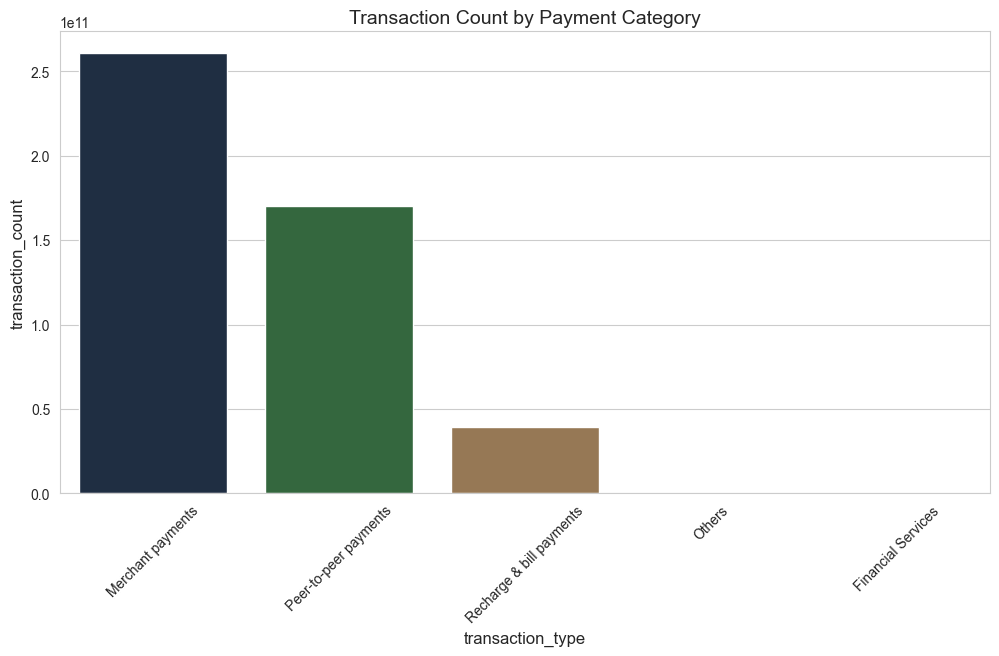

In [9]:
chart4 = aggregated_transaction.groupby("transaction_type", as_index=False)["transaction_count"].sum()
chart4 = chart4.sort_values("transaction_count", ascending=False)

sns.barplot(data=chart4, x="transaction_type", y="transaction_count", palette="cubehelix")
plt.title("Transaction Count by Payment Category")
plt.xticks(rotation=45)
plt.show()

### Why did you pick this chart?
A vertical bar chart is effective when comparing categories with clear labels.

### Insights found
This identifies the most frequently used payment categories by users.

### Business impact
This can support payment experience optimization, cashback strategies, and feature prioritization in the most-used categories.

# Chart 5: Year-wise Transaction Growth

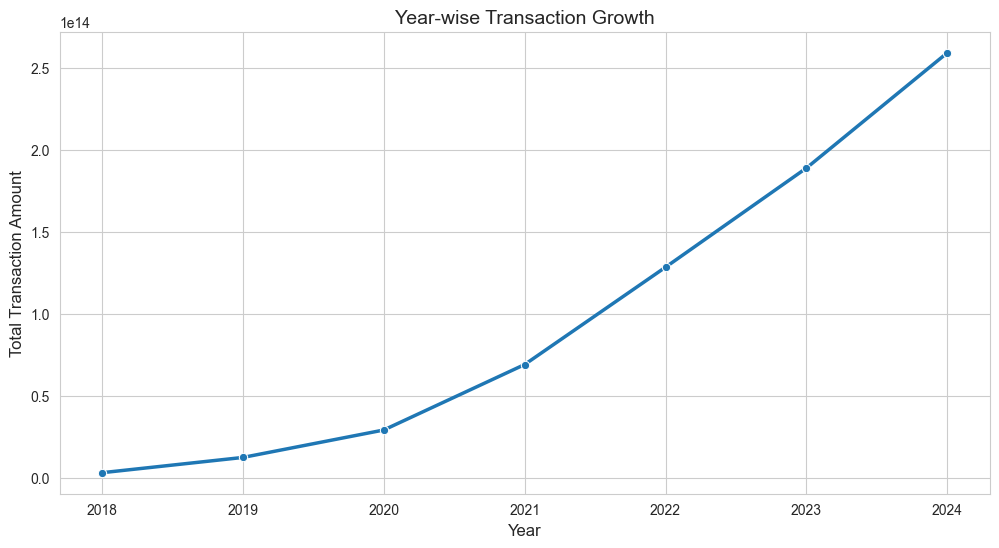

In [10]:
chart5 = aggregated_transaction.groupby("year", as_index=False)["transaction_amount"].sum()

sns.lineplot(data=chart5, x="year", y="transaction_amount", marker="o", linewidth=2.5)
plt.title("Year-wise Transaction Growth")
plt.xlabel("Year")
plt.ylabel("Total Transaction Amount")
plt.show()

### Why did you pick this chart?
A line chart is best for showing trends over time.

### Insights found
This chart shows whether digital payment usage is increasing year by year.

### Business impact
Growth patterns help in capacity planning, forecasting demand, and understanding long-term adoption.

# Chart 6: Quarter-wise Transaction Trend

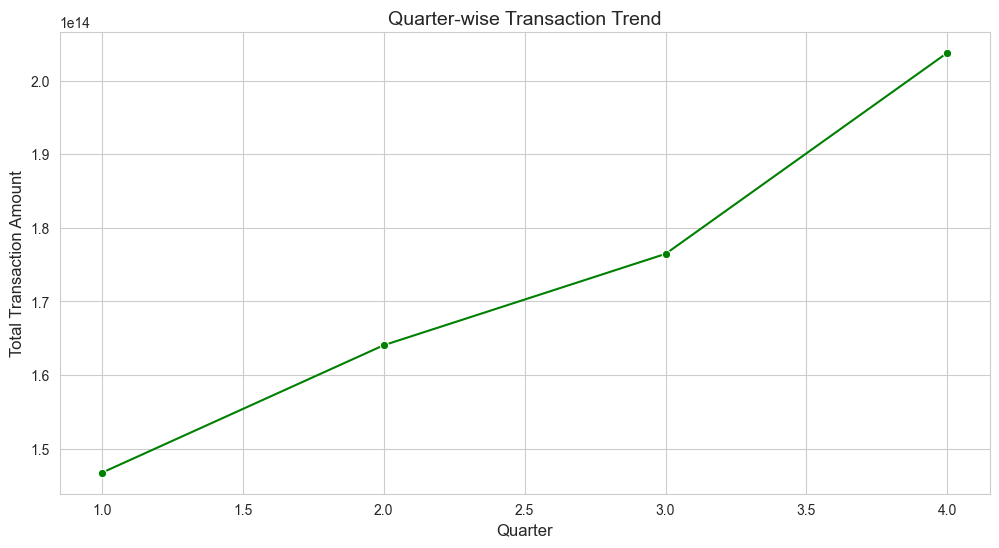

In [11]:
chart6 = aggregated_transaction.groupby("quarter", as_index=False)["transaction_amount"].sum()

sns.lineplot(data=chart6, x="quarter", y="transaction_amount", marker="o", color="green")
plt.title("Quarter-wise Transaction Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Transaction Amount")
plt.show()

### Why did you pick this chart?
Quarter-based line plots help identify seasonality and short-term fluctuations.

### Insights found
This chart helps detect which quarters perform best or worst.

### Business impact
The result can support campaign timing, budgeting, and seasonal feature rollouts.

# Chart 7: Top 10 Districts by Transaction Amount

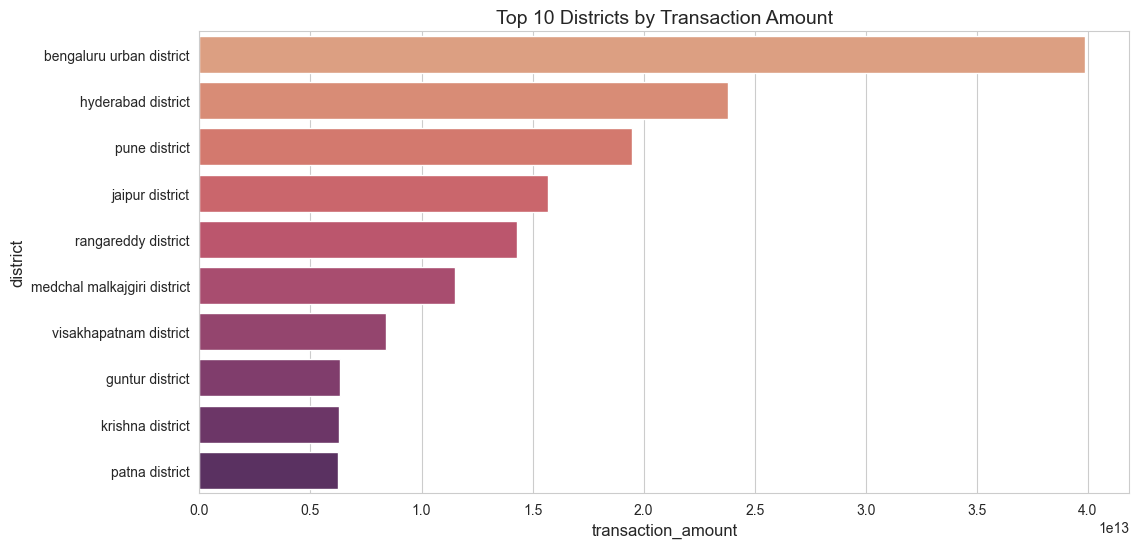

In [12]:
chart7 = map_transaction.groupby("district", as_index=False)["transaction_amount"].sum()
chart7 = chart7.sort_values("transaction_amount", ascending=False).head(10)

sns.barplot(data=chart7, x="transaction_amount", y="district", palette="flare")
plt.title("Top 10 Districts by Transaction Amount")
plt.show()

### Why did you pick this chart?
District-level comparisons work well with horizontal bars.

### Insights found
This chart identifies the strongest local markets beyond the state level.

### Business impact
It supports district-specific campaigns, merchant tie-ups, and local market expansion planning.

# Chart 8: Top 10 Pincodes by Transaction Count

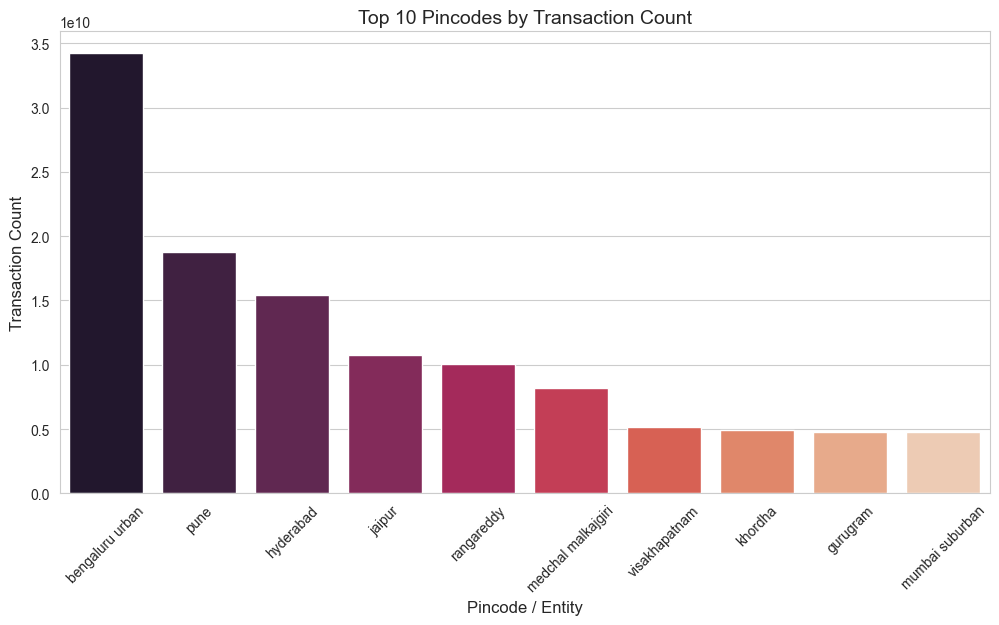

In [15]:
chart8 = top_transaction.groupby("entity_name", as_index=False)["transaction_count"].sum()
chart8 = chart8.sort_values("transaction_count", ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=chart8, x="entity_name", y="transaction_count", palette="rocket")
plt.title("Top 10 Pincodes by Transaction Count")
plt.xticks(rotation=45)
plt.xlabel("Pincode / Entity")
plt.ylabel("Transaction Count")
plt.show()

### Why did you pick this chart?
A bar chart is suitable for ranking top-performing pincodes.

### Insights found
The chart pinpoints hyper-local digital payment hotspots.

### Business impact
This can help micro-target offers and understand neighborhood-level digital adoption.

# Chart 9: State-wise Registered Users

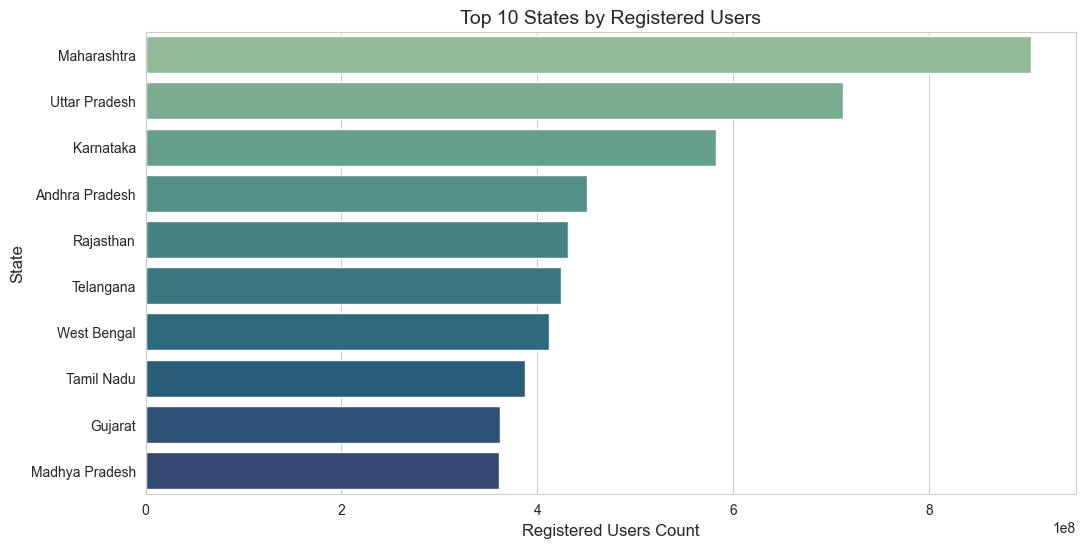

In [17]:
chart9 = aggregated_user.groupby("state", as_index=False)["count"].sum()
chart9 = chart9.rename(columns={"count": "registered_users"})
chart9 = chart9.sort_values("registered_users", ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=chart9, x="registered_users", y="state", palette="crest")
plt.title("Top 10 States by Registered Users")
plt.xlabel("Registered Users Count")
plt.ylabel("State")
plt.show()

### Why did you pick this chart?
A ranked bar chart quickly shows where user concentration is highest.

### Insights found
This chart identifies states with the largest digital payment user base.

### Business impact
It can be used for user acquisition planning and long-term retention strategies.

# Chart 10: State-wise App Opens

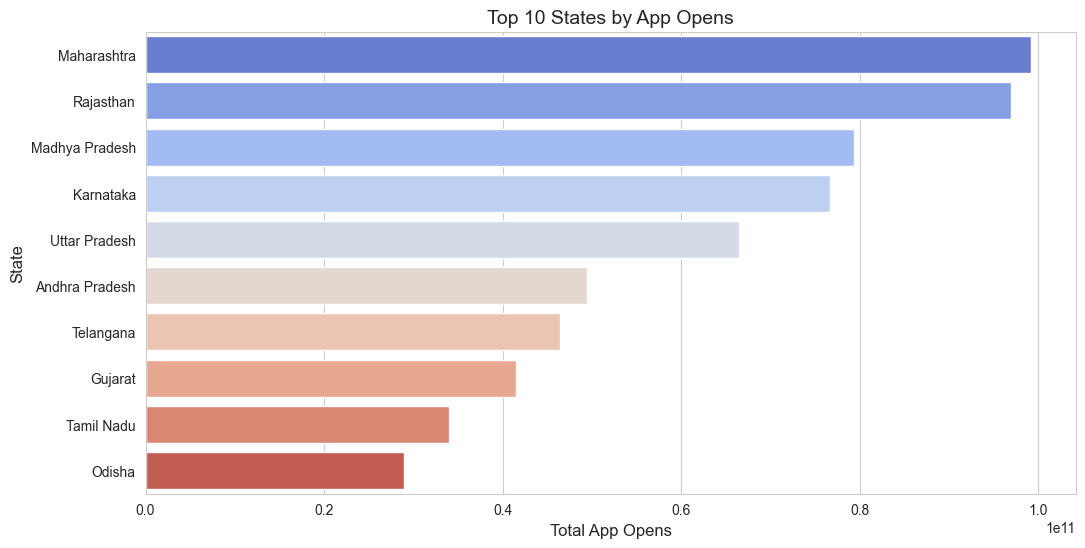

In [19]:
chart10 = map_user.groupby("state", as_index=False)["app_opens"].sum()
chart10 = chart10.sort_values("app_opens", ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=chart10, x="app_opens", y="state", palette="coolwarm")
plt.title("Top 10 States by App Opens")
plt.xlabel("Total App Opens")
plt.ylabel("State")
plt.show()

### Why did you pick this chart?
A bar chart is appropriate for comparing app engagement across states.

### Insights found
The chart shows where users are most active within the app ecosystem.

### Business impact
A high number of app opens indicates stronger engagement and better cross-sell potential.

# Chart 11: Insurance Transaction Amount by State

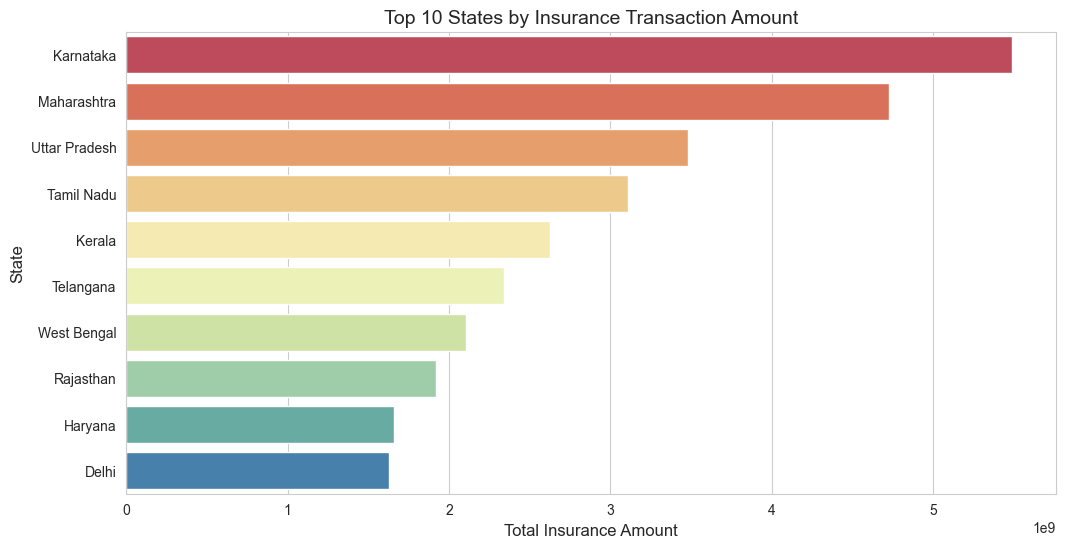

In [22]:
chart11 = aggregated_insurance.groupby("state", as_index=False)["transaction_amount"].sum()
chart11 = chart11.rename(columns={"transaction_amount": "insurance_amount"})
chart11 = chart11.sort_values("insurance_amount", ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=chart11, x="insurance_amount", y="state", palette="Spectral")
plt.title("Top 10 States by Insurance Transaction Amount")
plt.xlabel("Total Insurance Amount")
plt.ylabel("State")
plt.show()

### Why did you pick this chart?
A ranked bar chart helps reveal insurance-leading regions clearly.

### Insights found
This chart highlights states with strong insurance uptake.

### Business impact
It can support targeted insurance campaigns and help improve regional product strategy.

# Chart 12: Insurance Trend Over Years

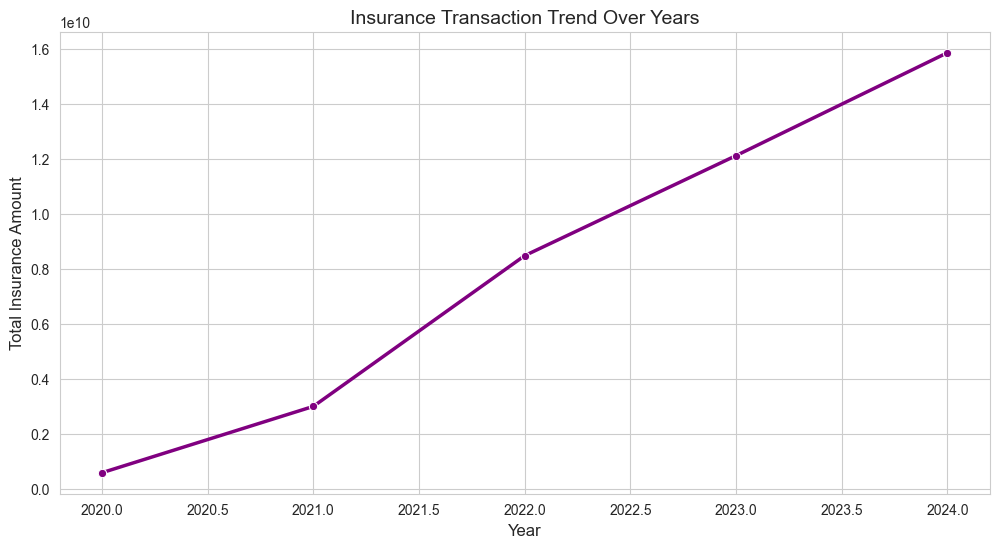

In [25]:
chart12 = aggregated_insurance.groupby("year", as_index=False)["transaction_amount"].sum()
chart12 = chart12.rename(columns={"transaction_amount": "insurance_amount"})

plt.figure(figsize=(12, 6))
sns.lineplot(data=chart12, x="year", y="insurance_amount", marker="o", color="purple", linewidth=2.5)
plt.title("Insurance Transaction Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Total Insurance Amount")
plt.show()

### Why did you pick this chart?
A line chart is ideal for measuring change over time.

### Insights found
This helps assess whether insurance usage is growing steadily or unevenly.

### Business impact
It supports forecasting, growth strategy, and insurance product scaling decisions.

# Chart 13: Heatmap of Transaction Amount by State and Quarter

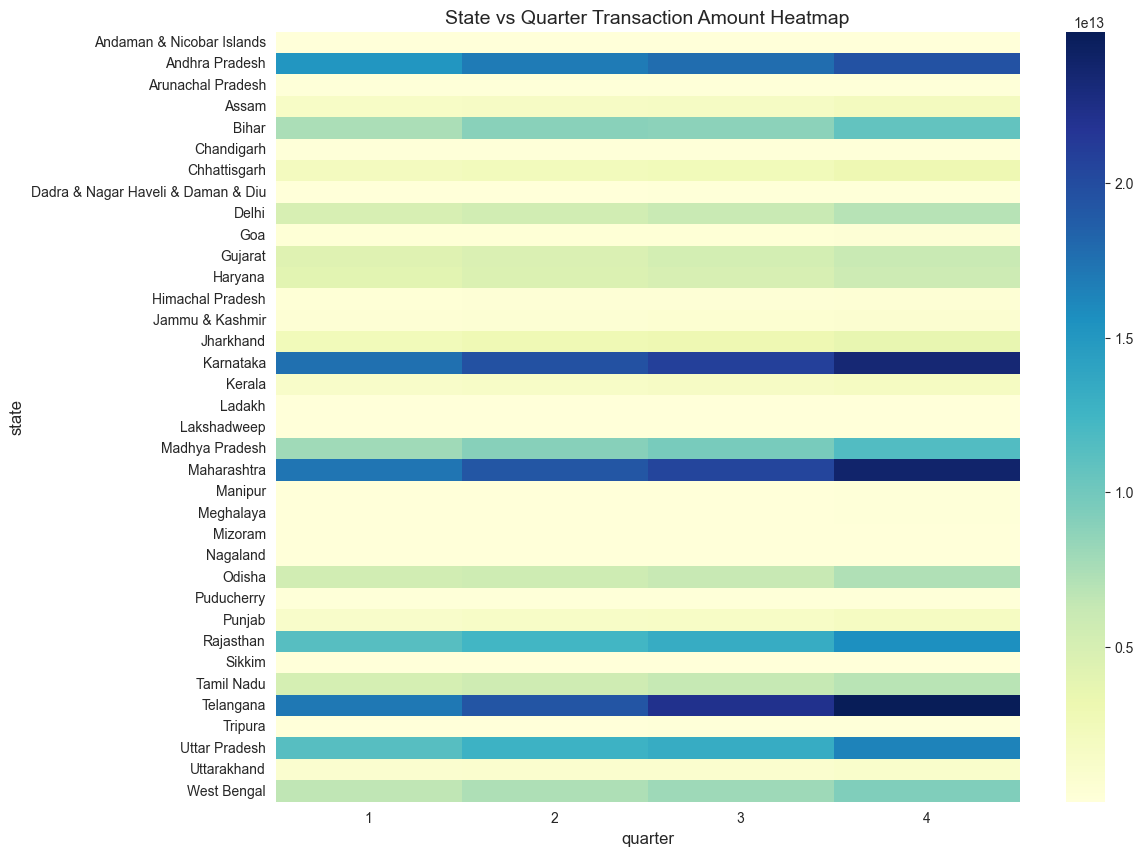

In [26]:
chart13 = aggregated_transaction.pivot_table(values="transaction_amount", index="state", columns="quarter", aggfunc="sum")
plt.figure(figsize=(12,10))
sns.heatmap(chart13, cmap="YlGnBu")
plt.title("State vs Quarter Transaction Amount Heatmap")
plt.show()

### Why did you pick this chart?
A heatmap helps compare many state-quarter combinations at once.

### Insights found
This chart shows regional and seasonal concentration patterns in one view.

### Business impact
It supports campaign timing and regional planning with higher precision.

# Chart 14: Correlation Heatmap

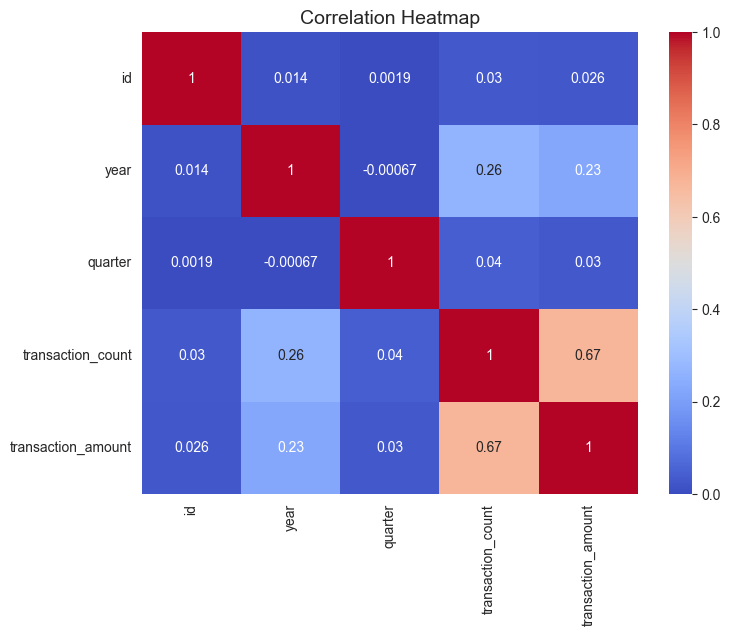

In [27]:
numeric_df = aggregated_transaction.select_dtypes(include=np.number)
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Why did you pick this chart?
A correlation heatmap helps identify relationships between numerical variables.

### Insights found
It shows whether transaction count, amount, and time-based variables move together.

### Business impact
This can help decide which metrics should be tracked together in the dashboard.

# Chart 15: Registered Users vs App Opens

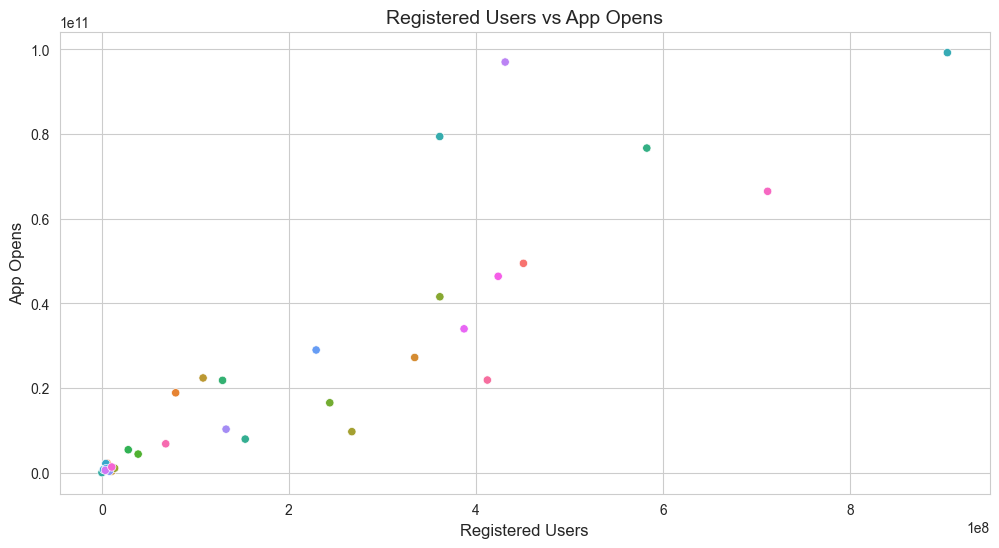

In [29]:
# 1. Get total registered users per state from aggregated_user
users_df = aggregated_user.groupby("state", as_index=False)["count"].sum()
users_df = users_df.rename(columns={"count": "registered_users"})

# 2. Get total app opens per state from map_user
opens_df = map_user.groupby("state", as_index=False)["app_opens"].sum()

# 3. Merge the two datasets on the 'state' column
chart15 = pd.merge(users_df, opens_df, on="state")

# 4. Plot the scatterplot
plt.figure(figsize=(12, 6))
sns.scatterplot(data=chart15, x="registered_users", y="app_opens", hue="state", legend=False)
plt.title("Registered Users vs App Opens")
plt.xlabel("Registered Users")
plt.ylabel("App Opens")
plt.show()

### Why did you pick this chart?
A scatter plot helps identify the relationship between user base and engagement.

### Insights found
States with many registered users but relatively lower app opens may indicate weaker engagement.

### Business impact
This helps identify retention gaps and states where onboarding is good but repeat usage is weak.

# Overall Findings from Visualization

- Transaction activity is concentrated in a limited set of top-performing states and districts.
- Payment categories vary in both value contribution and usage frequency.
- User engagement and registered user growth are not always proportional.
- Insurance activity appears to have regional concentration and growth opportunity.
- Temporal trends support campaign planning by year and quarter.

These charts collectively support customer segmentation, payment performance analysis, geographic targeting, user engagement strategy, and product expansion decisions.